In [1]:
#Librerías y config. gráficos

import numpy as np
import matplotlib.pyplot as plt
import time

def initialize_plotting():
    import matplotlib as mpl
    %config InlineBackend.figure_format = 'svg'
    label_size = 20
    mpl.rcParams['xtick.labelsize'] = label_size
    mpl.rcParams['ytick.labelsize'] = label_size
    mpl.rcParams['legend.fontsize'] = 14
    plt.rc('font', family='serif')
    mpl.rcParams.update({'font.size': 16})
    mpl.rcParams['text.usetex'] = False
    mpl.rcParams['figure.dpi'] = 120
initialize_plotting()

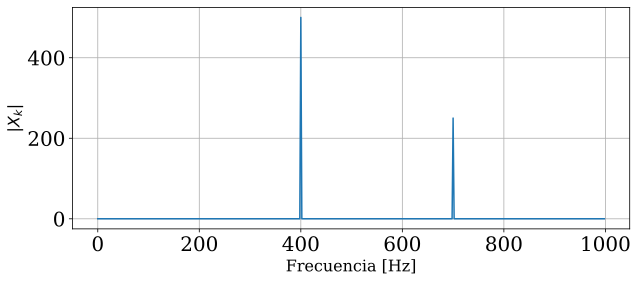

In [2]:
# inciso (a) generar señal compuesta

N_muestra = 1000 #numero de puntos que tendrá la señal
f_muestreo = 2000 #cuantos puntos por segundo se toman
t = np.linspace(0, 0.5, N_muestra, endpoint=False)

f1 = 400
f2 = 700
xn = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

#inciso (b)  Trans. discreta de Fourier

def Tfou_manual(x):
    N = len(x)
    X_k = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X_k[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    return X_k

X_fou_m = Tfou_manual(xn) # eje y del grafico

# calculamos el eje x
k_indices = np.arange(N_muestra)
frecuencias = k_indices * (f_muestreo / N_muestra)

magnitud = np.abs(X_fou_m) #magnitud del eje y

# inciso (c) graficamos 

plt.figure(figsize=(10, 4))
plt.plot(frecuencias[:N_muestra//2], magnitud[:N_muestra//2])
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("$|X_k|$")
plt.grid(True)
plt.show()

In [3]:
# incisos (d) definimos FFT 

def fft_numpy(x):
    return np.fft.fft(x)
# inciso (e) comparación con DFT

N_vals = [10**2, 10**3, 10**4, 10**5]
tiempos_dft = []
tiempos_fft = []

for N in N_vals:
    x_test = np.random.rand(N) #señal aleatoria de tamaño N

    inicio_dft = time.perf_counter()
    Tfou_manual(x_test)
    fin_dft = time.perf_counter()
    tiempos_dft.append(fin_dft - inicio_dft) # medimos el tiempo de Dft manual

    inicio_fft = time.perf_counter()
    fft_numpy(x_test)
    fin_fft = time.perf_counter()
    tiempos_fft.append(fin_fft - inicio_fft)

    print(f"N={N:<7} | DFT: {tiempos_dft[-1]:.4f} s | FFT: {tiempos_fft[-1]:.6f} s")
    

N=100     | DFT: 0.0122 s | FFT: 0.003538 s
N=1000    | DFT: 1.1967 s | FFT: 0.000078 s
N=10000   | DFT: 117.6476 s | FFT: 0.000257 s
N=100000  | DFT: 28059.4299 s | FFT: 0.002029 s


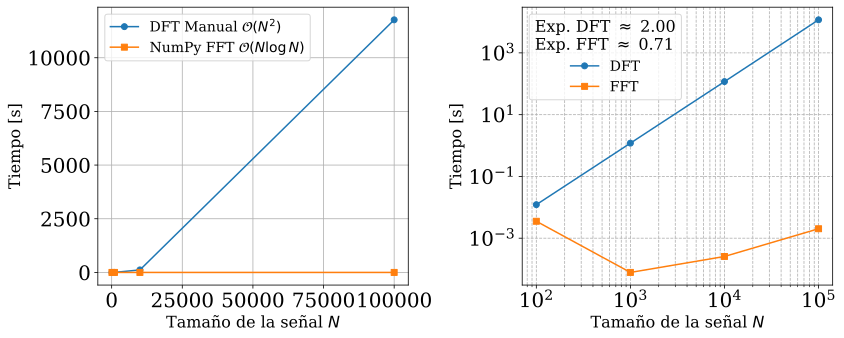

In [6]:
# inciso (f) graficamos ambos algoritmos

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(N_vals, tiempos_dft, marker='o', label='DFT Manual $\mathcal{O}(N^2)$')
plt.plot(N_vals, tiempos_fft, marker='s', label='NumPy FFT $\mathcal{O}(N \log N)$')
plt.xlabel('Tamaño de la señal $N$')
plt.ylabel('Tiempo [s]')
plt.legend()
plt.grid(True)

# inciso (g) escala log y estimacion 
plt.subplot(1, 2, 2)
plt.loglog(N_vals, tiempos_dft, marker='o', label='DFT')
plt.loglog(N_vals, tiempos_fft, marker='s', label='FFT')
plt.xlabel('Tamaño de la señal $N$')
plt.ylabel('Tiempo [s]')
plt.grid(True, which="both", ls="--")

# ignoramos N=100 porque los tiempos muy cortos tienen ruido del sistema
log_N = np.log(N_vals[1:])
pend_dft, _ = np.polyfit(log_N, np.log(tiempos_dft[1:]), 1)
pend_fft, _ = np.polyfit(log_N, np.log(tiempos_fft[1:]), 1)

plt.legend(title=f"Exp. DFT $\\approx$ {pend_dft:.2f}\nExp. FFT $\\approx$ {pend_fft:.2f}")
plt.tight_layout()
plt.show()